# Evaluating LFADS multi-run (hyperparameter search) outputs

This notebook evaluates the results of `run_multi.py`, a Ray Tune random-search
over five regularisation hyperparameters.

**Section 1 — Hyperparameter search overview**
1. Learning curves for all completed trials
2. Hyperparameter scatter vs. final validation loss

**Section 2 — Best model evaluation** (identical to `evaluate_single`)
3. Example trial rasters — raw spikes vs. LFADS inferred rates
4. PSTH comparison — condition-averaged rates vs. ground-truth
5. Velocity decoding — linear R² from factors vs. raw spikes
6. Factor state-space — PCA trajectories coloured by condition
7. IC posterior distribution — 2D PCA scatter of initial condition means

In [1]:
import json
from glob import glob
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib import cm
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.preprocessing import StandardScaler

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

## Path configuration

Set any of the three variables below to `None` to use auto-detection, or
override with explicit paths to pin specific runs.

- `MULTI_DIR` — the root directory created by `run_multi.py` (contains all trial sub-dirs)
- `BEST_TRIAL_DIR` — pin a specific trial; `None` → auto-select by lowest `valid/recon_smth`
- `H5_PATH` — pin a specific `lfads_output*.h5`; `None` → auto-detect in best trial dir

In [2]:
MULTI_DIR      = None  # e.g. "../runs/lfads-torch-example/nlb_mc_maze/260520_exampleMulti"
BEST_TRIAL_DIR = None  # e.g. "../runs/.../260520_exampleMulti/run_model_xxxx_00003"
H5_PATH        = None  # e.g. "../runs/.../run_model_xxxx_00003/lfads_output_mc_maze-20ms-val.h5"

if MULTI_DIR is None:
    candidates = sorted(
        glob("../runs/**/*Multi*/", recursive=True),
        key=lambda p: Path(p).stat().st_mtime,
    )
    assert candidates, "No multi-run directory found. Run run_multi.py first."
    MULTI_DIR = candidates[-1]

MULTI_DIR = Path(MULTI_DIR)
print(f"Multi-run directory: {MULTI_DIR}")

Multi-run directory: ../runs/lfads-torch-example/nlb_mc_maze/260520_exampleMulti


## Section 1 — Hyperparameter search overview

### Load all trial results

Each trial directory contains a `result.json` (line-delimited JSON, one record per epoch)
and a `params.json` with the hyperparameter values used for that trial.
We aggregate these into a single DataFrame and identify the best trial.

In [3]:
HP_COLS = ["dropout_rate", "kl_co_scale", "kl_ic_scale", "l2_gen_scale", "l2_con_scale"]
METRIC  = "valid/recon_smth"

rows       = []
epoch_data = {}

for result_path in sorted(MULTI_DIR.glob("run_model_*/result.json")):
    trial_dir = result_path.parent
    trial_id  = trial_dir.name

    params_path = trial_dir / "params.json"
    if not params_path.exists():
        continue
    with open(params_path) as f:
        raw_params = json.load(f)
    hps = {k.replace("model.", ""): v for k, v in raw_params.items() if "model." in k}

    with open(result_path) as f:
        records = [json.loads(line) for line in f if line.strip()]

    valid_records = [r for r in records if METRIC in r and r[METRIC] is not None]

    if not valid_records:
        row = {"trial_id": trial_id, "trial_dir": str(trial_dir), "status": "error",
               "best_recon_smth": np.nan, "best_epoch": np.nan}
        row.update({k: hps.get(k, np.nan) for k in HP_COLS})
        rows.append(row)
        continue

    best_rec = min(valid_records, key=lambda r: r[METRIC])
    epoch_data[trial_id] = {
        "epochs":     [r.get("cur_epoch", i) for i, r in enumerate(valid_records)],
        "recon_smth": [r[METRIC] for r in valid_records],
    }
    row = {
        "trial_id":        trial_id,
        "trial_dir":       str(trial_dir),
        "status":          "completed",
        "best_recon_smth": best_rec[METRIC],
        "best_epoch":      best_rec.get("cur_epoch", best_rec.get("training_iteration")),
    }
    row.update({k: hps.get(k, np.nan) for k in HP_COLS})
    rows.append(row)

df        = pd.DataFrame(rows)
completed = df[df["status"] == "completed"].sort_values("best_recon_smth").reset_index(drop=True)

print(f"Trials: {len(df)} total, {len(completed)} completed, "
      f"{(df['status'] == 'error').sum()} errored")
print("\nTop-10 trials by best valid/recon_smth:")
display(completed[["trial_id", "best_recon_smth", "best_epoch"] + HP_COLS].head(10))

if BEST_TRIAL_DIR is None:
    assert len(completed) > 0, (
        "No completed trials found. Check that run_multi.py finished successfully."
    )
    BEST_TRIAL_DIR = Path(completed.iloc[0]["trial_dir"])

BEST_TRIAL_DIR = Path(BEST_TRIAL_DIR)
best_trial_id  = BEST_TRIAL_DIR.name
print(f"\nBest trial : {best_trial_id}")
print(f"  recon_smth = {completed.iloc[0]['best_recon_smth']:.4f}"
      f"  at epoch {int(completed.iloc[0]['best_epoch'])}")

Trials: 69 total, 9 completed, 60 errored

Top-10 trials by best valid/recon_smth:


,trial_id,best_recon_smth,best_epoch,dropout_rate,kl_co_scale,kl_ic_scale,l2_gen_scale,l2_con_scale
0,run_model_7ec2b_00000,0.211319,686.0,0.382177,0.000003,0.000001,0.000116,0.179094
1,run_model_7ec2b_00003,0.211615,343.0,0.105393,0.000053,0.000042,0.001581,0.004906
2,run_model_7ec2b_00006,0.211731,432.0,0.413068,0.000006,0.000003,0.076905,0.012630
3,run_model_7ec2b_00002,0.211843,995.0,0.489512,0.000001,0.000373,0.000136,0.082913
4,run_model_7ec2b_00004,0.211890,161.0,0.016992,0.000002,0.000103,0.038793,0.028943
5,run_model_7ec2b_00007,0.211971,344.0,0.186145,0.000009,0.000466,0.544721,0.002699
6,run_model_7ec2b_00008,0.212023,322.0,0.342918,0.000004,0.000061,0.002247,0.003685
7,run_model_7ec2b_00001,0.212679,997.0,0.547653,0.000016,0.000154,0.014945,0.549908
8,run_model_7ec2b_00005,0.212695,498.0,0.230207,0.000099,0.000876,0.055229,0.039979



Best trial : run_model_7ec2b_00000
  recon_smth = 0.2113  at epoch 686


## Fig 0a — Learning curves

Each line is one completed trial. The best trial is highlighted in red.

**What to look for:** All trials should decrease and then plateau — any trial that
never decreases likely had too-strong regularisation. The spread across trials at
convergence shows how sensitive performance is to the hyperparameter choice.

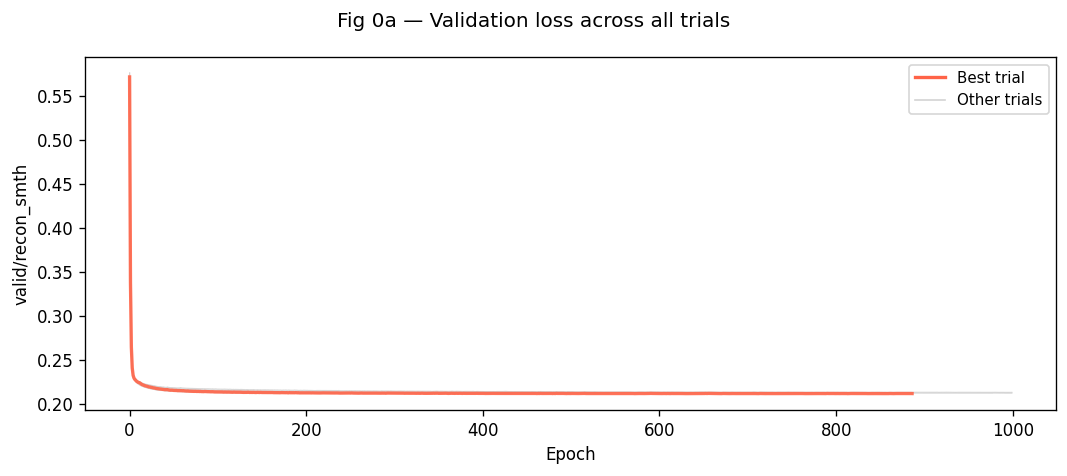

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
for tid, ed in epoch_data.items():
    is_best = tid == best_trial_id
    ax.plot(
        ed["epochs"], ed["recon_smth"],
        color="tomato" if is_best else "lightgrey",
        lw=2.0 if is_best else 0.7,
        zorder=3 if is_best else 1,
        alpha=0.9,
    )
ax.set_xlabel("Epoch")
ax.set_ylabel("valid/recon_smth")
ax.legend(handles=[
    Line2D([0], [0], color="tomato",    lw=2, label="Best trial"),
    Line2D([0], [0], color="lightgrey", lw=1, label="Other trials"),
], fontsize=9)
fig.suptitle("Fig 0a — Validation loss across all trials", fontsize=12)
plt.tight_layout()
fig.savefig(BEST_TRIAL_DIR / "fig0a_learning_curves.png", dpi=120)

## Fig 0b — Hyperparameter search results

One scatter panel per hyperparameter. X axis = hyperparameter value,
Y axis = best `valid/recon_smth` achieved by that trial.
Colour = percentile rank (green = low loss = good, red = high loss = poor).
The best trial is marked with a red star.

**What to look for:** A strong trend in any panel means that hyperparameter
is important. A flat cloud means it doesn't matter much in the range sampled.

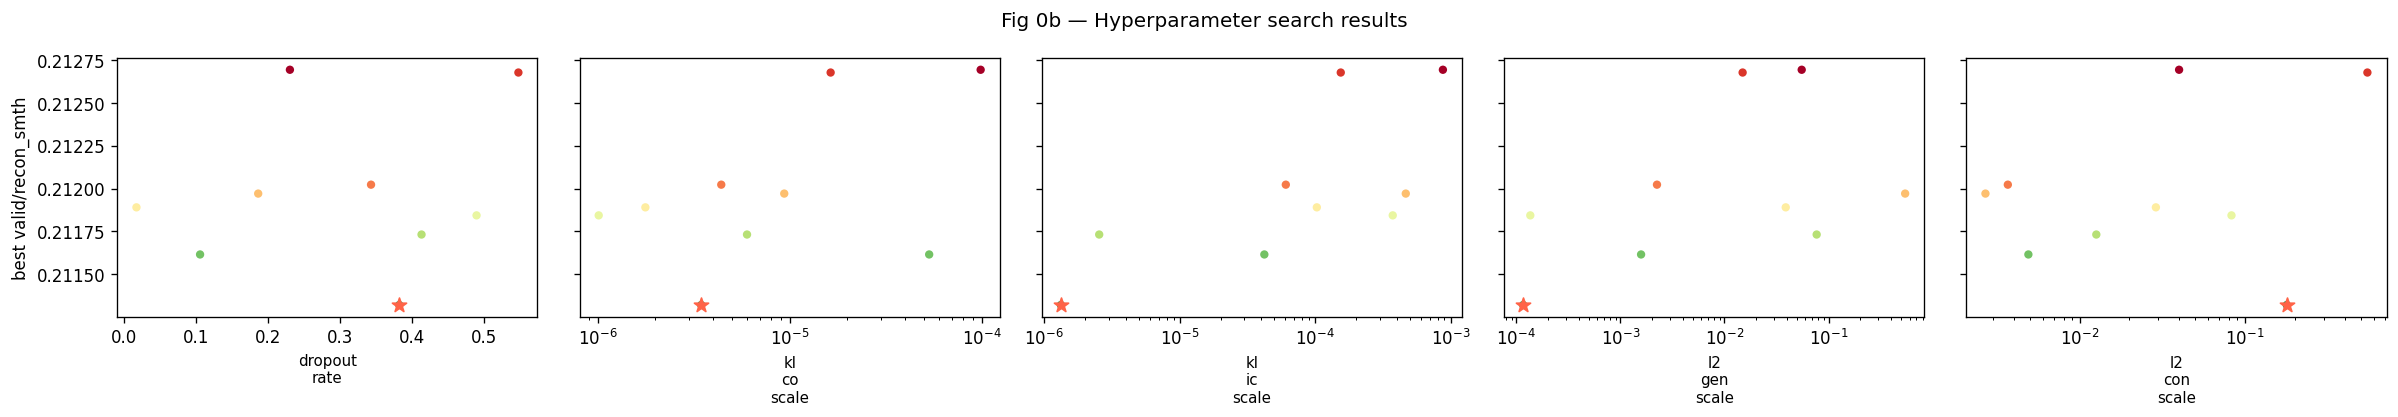

In [5]:
LOG_PARAMS = {"kl_co_scale", "kl_ic_scale", "l2_gen_scale", "l2_con_scale"}

sub       = completed.dropna(subset=HP_COLS + ["best_recon_smth"]).copy()
ranks     = sub["best_recon_smth"].rank(pct=True).values
colors_hp = [cm.RdYlGn(1 - r) for r in ranks]

fig, axes = plt.subplots(1, len(HP_COLS), figsize=(4 * len(HP_COLS), 3.5), squeeze=False)
for ci, hp in enumerate(HP_COLS):
    ax = axes[0, ci]
    ax.scatter(sub[hp], sub["best_recon_smth"], c=colors_hp, s=25, edgecolors="none")
    if len(completed) > 0:
        ax.scatter(
            completed.iloc[0][hp], completed.iloc[0]["best_recon_smth"],
            color="tomato", s=80, zorder=5, marker="*", label="Best",
        )
    ax.set_xlabel(hp.replace("_", "\n"), fontsize=9)
    if hp in LOG_PARAMS:
        ax.set_xscale("log")
    if ci == 0:
        ax.set_ylabel("best valid/recon_smth")
    else:
        ax.set_yticklabels([])
fig.suptitle("Fig 0b — Hyperparameter search results", fontsize=12)
plt.tight_layout()
fig.savefig(BEST_TRIAL_DIR / "fig0b_hp_search.png", dpi=120)

---
## Section 2 — Best model evaluation

### Load the HDF5 output file

After training, `run_multi.py` runs posterior sampling on the best checkpoint of
each trial, producing `lfads_output*.h5` in the trial directory.
We load the best trial's file here.

In [6]:
if H5_PATH is None:
    h5_candidates = sorted(BEST_TRIAL_DIR.glob("lfads_output*.h5"))
    assert h5_candidates, (
        f"No lfads_output*.h5 found in {BEST_TRIAL_DIR}.\n"
        "Posterior sampling may not have run yet — wait for run_multi.py to finish, "
        "or set H5_PATH manually."
    )
    H5_PATH = h5_candidates[0]

H5_PATH = Path(H5_PATH)
print(f"Loading: {H5_PATH}")

with h5py.File(H5_PATH) as f:
    d = {k: f[k][()] for k in f}

N_OBS = d["valid_encod_data"].shape[1]
print(f"  encod_seq_len = {N_OBS}")
print(f"  recon_seq_len = {d['valid_output_params'].shape[1]}")
print(f"  n_neurons     = {d['valid_output_params'].shape[2]}")
print(f"  n_factors     = {d['valid_factors'].shape[2]}")
print(f"  n_conditions  = {len(d['valid_cond_idx'])}")
print(f"  train trials  = {len(d['train_factors'])}")
print(f"  valid trials  = {len(d['valid_factors'])}")

Loading: ../runs/lfads-torch-example/nlb_mc_maze/260520_exampleMulti/run_model_7ec2b_00000/lfads_output_mc_maze-20ms-val.h5
  encod_seq_len = 35
  recon_seq_len = 45
  n_neurons     = 182
  n_factors     = 100
  n_conditions  = 108
  train trials  = 1721
  valid trials  = 574


In [7]:
def cond_labels(cond_idx, n_trials):
    """Convert ragged cond_idx to a flat per-trial integer label array (-1 = unlabelled)."""
    labels = np.full(n_trials, -1, dtype=int)
    for c, idxs in enumerate(cond_idx):
        labels[idxs] = c
    return labels

## Fig 1 — Input spikes vs. LFADS inferred rates

Each row is one validation trial. Left: raw binned spike counts fed to the encoder.
Right: the posterior-averaged firing rates predicted by LFADS, trimmed to the encoder window.

**What to look for:** Rates should be a smooth, denoised version of the spikes.
Compare to the single-run result — a better-regularised multi-run model should show
smoother rates with less residual noise.

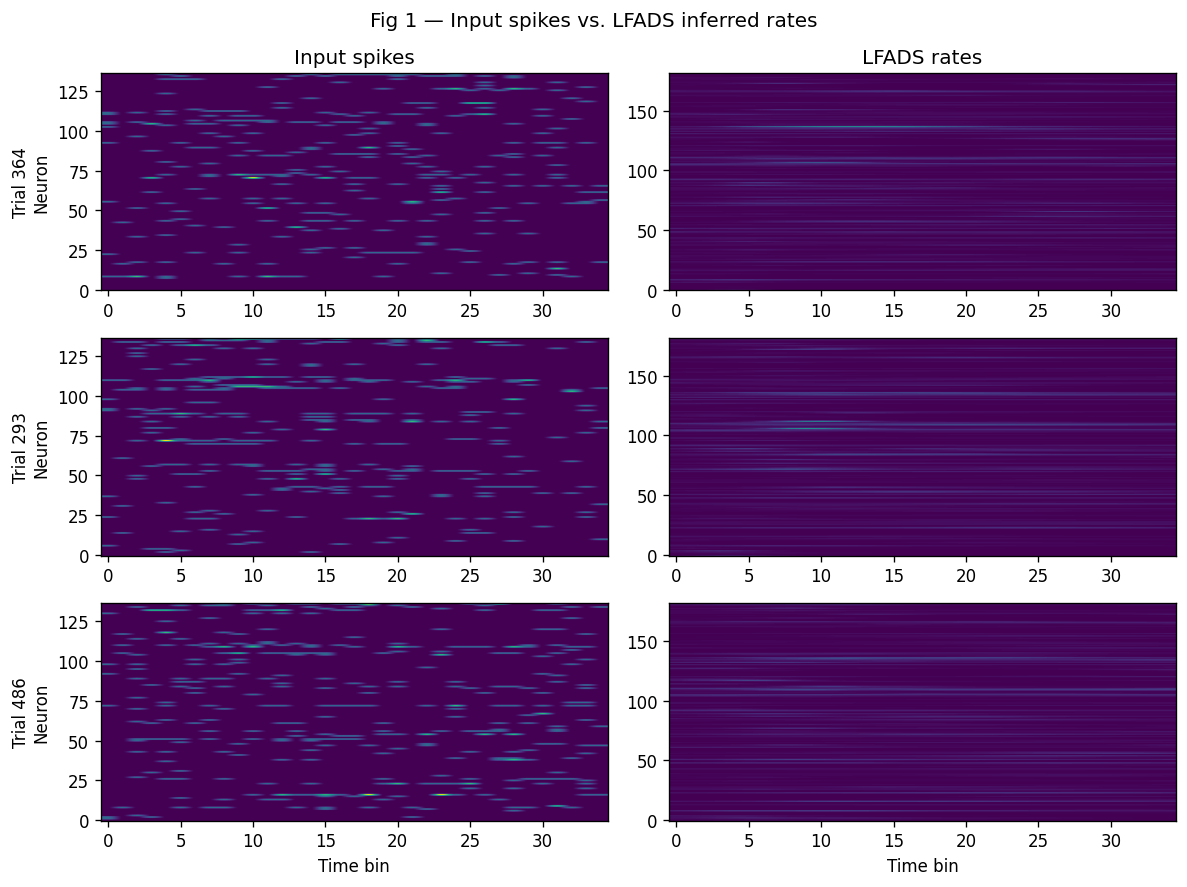

In [8]:
N_EXAMPLE_TRIALS = 3
rng = np.random.default_rng(0)

encod     = d["valid_encod_data"].astype(float)
rates_obs = d["valid_output_params"][:, :N_OBS, :].astype(float)

idx  = rng.choice(len(encod), size=N_EXAMPLE_TRIALS, replace=False)
vmax = max(encod[idx].max(), rates_obs[idx].max())

fig, axes = plt.subplots(N_EXAMPLE_TRIALS, 2, figsize=(10, 2.5 * N_EXAMPLE_TRIALS))
for row, i in enumerate(idx):
    for col, (arr, title) in enumerate(
        [(encod[i], "Input spikes"), (rates_obs[i], "LFADS rates")]
    ):
        ax = axes[row, col]
        ax.imshow(arr.T, aspect="auto", vmin=0, vmax=vmax, origin="lower")
        if row == 0:
            ax.set_title(title)
        ax.set_ylabel(f"Trial {i}\nNeuron" if col == 0 else "")
for ax in axes[-1]:
    ax.set_xlabel("Time bin")
fig.suptitle("Fig 1 — Input spikes vs. LFADS inferred rates", fontsize=12)
plt.tight_layout()
fig.savefig(BEST_TRIAL_DIR / "fig1_example_trials.png", dpi=120)

## Fig 2 — PSTH comparison

Blue = ground-truth condition-averaged PSTH; red = LFADS predicted PSTH.
PSTH R² near 1 means the model captured trial-averaged dynamics accurately.

**What to look for:** R² should be ≥ the single-run value if the multi-run found
better regularisation.

PSTH R² = 0.9261


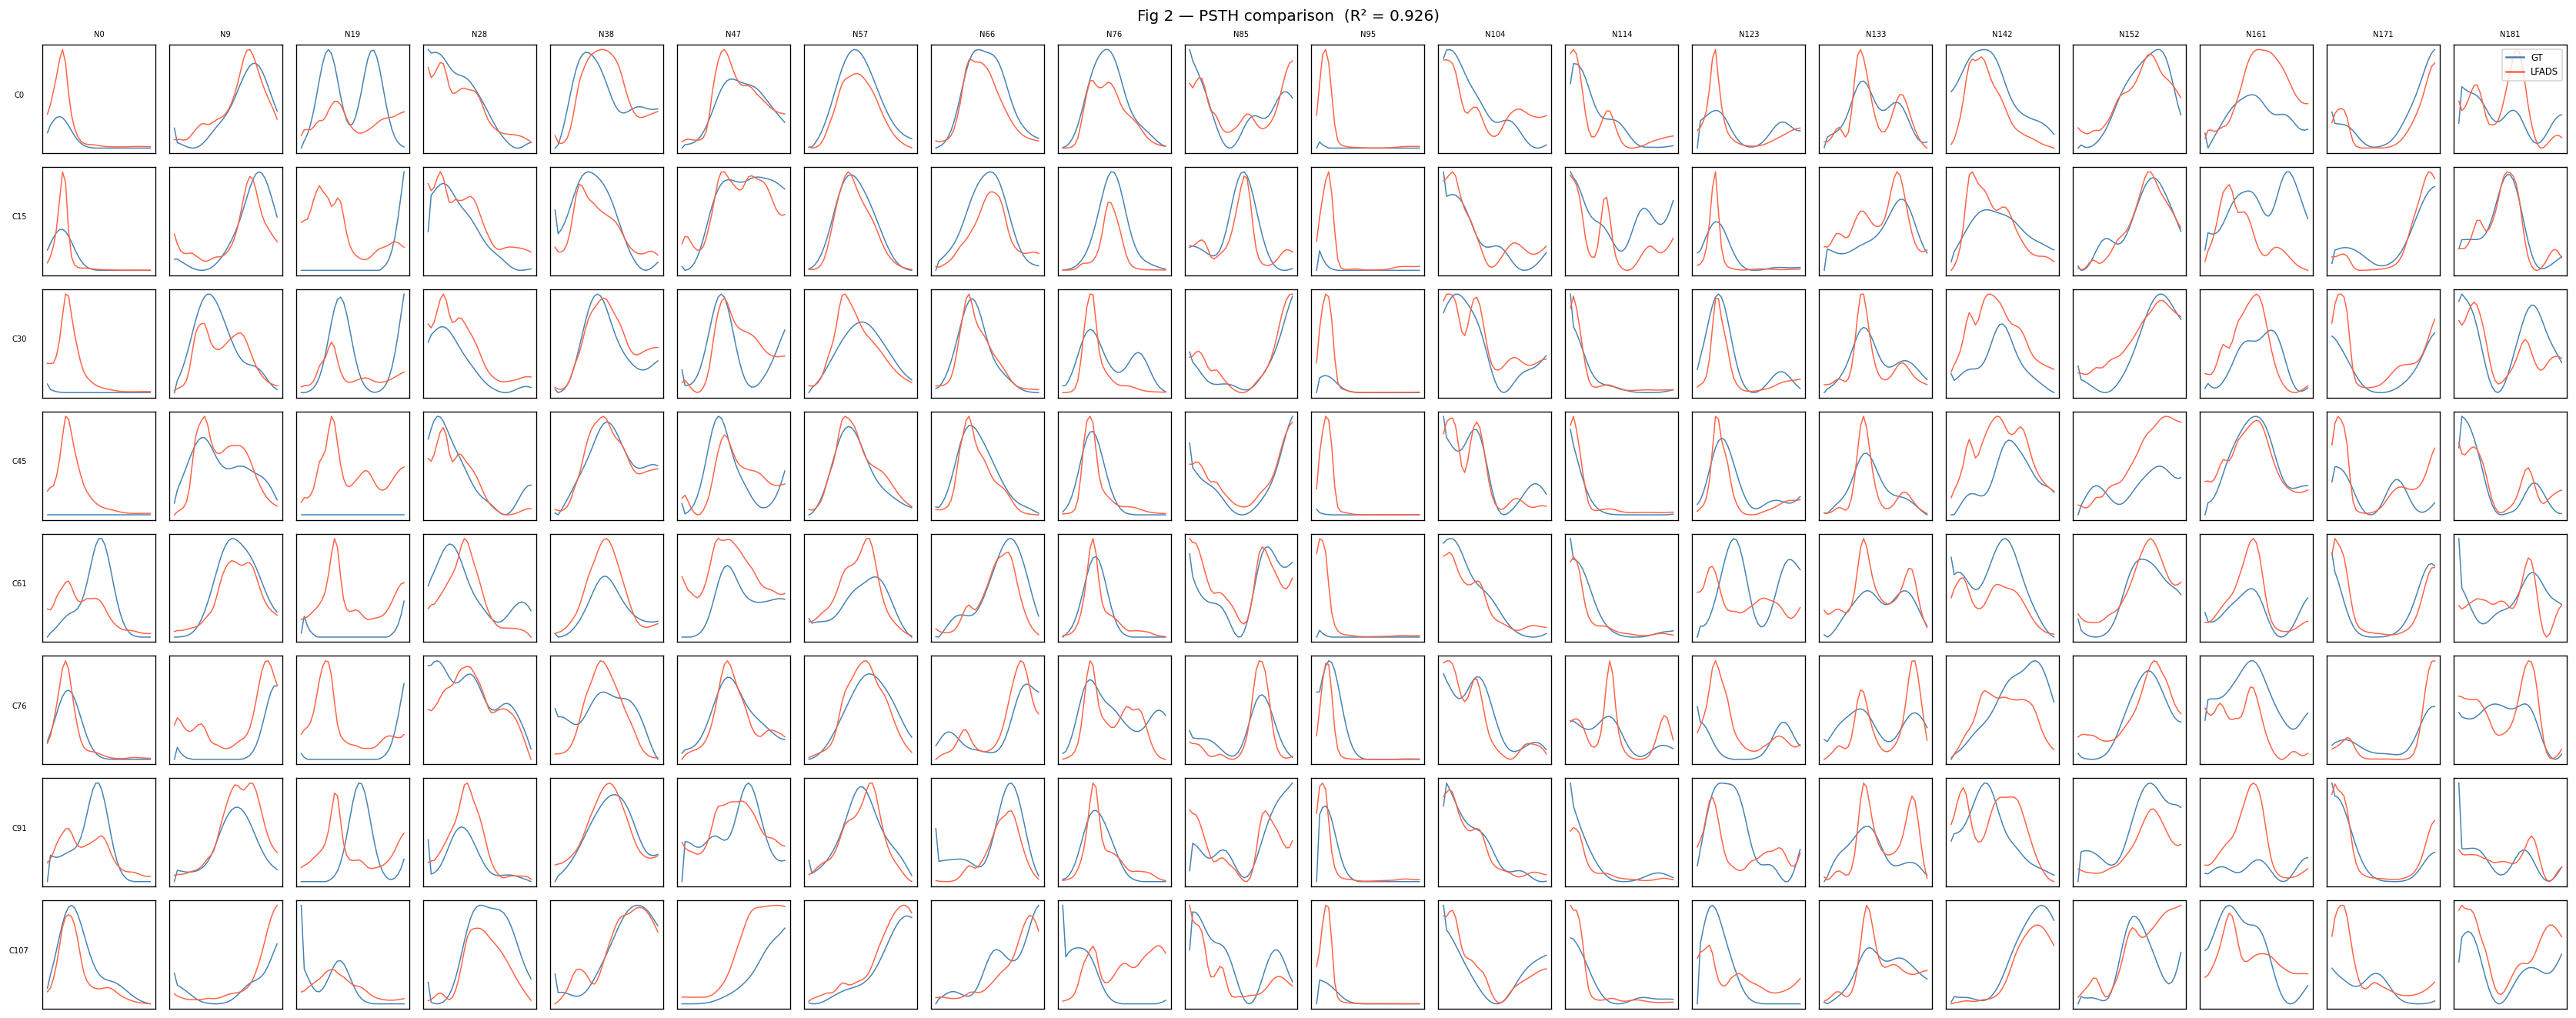

In [9]:
N_PSTH_NEURONS = 20
N_PSTH_CONDS   = 8

psth_gt   = d["psth"].astype(float)
cond_idx  = d["valid_cond_idx"]
n_conds   = len(cond_idx)

pred_psth = np.full_like(psth_gt, np.nan)
for c, idxs in enumerate(cond_idx):
    if len(idxs) > 0:
        pred_psth[c] = rates_obs[idxs].mean(axis=0)

mask    = ~np.isnan(pred_psth).any(axis=(1, 2))
g, p    = psth_gt[mask].ravel(), pred_psth[mask].ravel()
psth_r2 = 1.0 - np.sum((g - p) ** 2) / np.sum((g - g.mean()) ** 2)
print(f"PSTH R² = {psth_r2:.4f}")

sel_conds   = np.linspace(0, n_conds - 1, N_PSTH_CONDS, dtype=int)
sel_neurons = np.linspace(0, psth_gt.shape[2] - 1, N_PSTH_NEURONS, dtype=int)
t = np.arange(N_OBS)

fig, axes = plt.subplots(
    N_PSTH_CONDS, N_PSTH_NEURONS,
    figsize=(N_PSTH_NEURONS * 1.4, N_PSTH_CONDS * 1.4),
    squeeze=False,
)
for ri, c in enumerate(sel_conds):
    for ci, n in enumerate(sel_neurons):
        ax = axes[ri, ci]
        ax.plot(t, psth_gt[c, :, n],   color="steelblue", lw=0.9)
        ax.plot(t, pred_psth[c, :, n], color="tomato",    lw=0.9)
        ax.set_xticks([]); ax.set_yticks([])
        if ri == 0:
            ax.set_title(f"N{n}", fontsize=6)
    axes[ri, 0].set_ylabel(f"C{c}", fontsize=6, rotation=0, labelpad=18)
axes[0, -1].legend(
    handles=[
        Line2D([0], [0], color="steelblue", lw=1.5, label="GT"),
        Line2D([0], [0], color="tomato",    lw=1.5, label="LFADS"),
    ],
    fontsize=7, loc="upper right", framealpha=0.8,
)
fig.suptitle(f"Fig 2 — PSTH comparison  (R² = {psth_r2:.3f})", fontsize=12)
plt.tight_layout()
fig.savefig(BEST_TRIAL_DIR / "fig2_psth.png", dpi=120)

## Fig 3 — Velocity decoding

Ridge regression trained on the training set, evaluated on the validation set.
Two feature sets compared: LFADS factors vs. raw spike counts.

**What to look for:** Factors R² >> raw spikes R² confirms denoising improved
the movement-relevant signal. The multi-run best model should match or exceed
the single-run decoding performance.

Factors R²  — x: 0.895, y: 0.843, mean: 0.869
Spikes  R²  — x: 0.260, y: 0.208, mean: 0.234


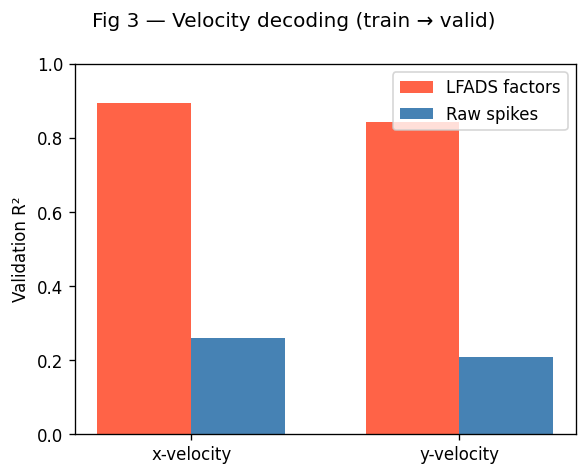

In [10]:
def decode_velocity(x_tr, y_tr, x_va, y_va):
    n_trials, n_time, n_feat = x_tr.shape
    groups  = np.repeat(np.arange(n_trials), n_time)
    x_tr_f  = x_tr.reshape(-1, n_feat);  y_tr_f = y_tr.reshape(-1, y_tr.shape[-1])
    x_va_f  = x_va.reshape(-1, n_feat);  y_va_f = y_va.reshape(-1, y_va.shape[-1])
    model   = GridSearchCV(Ridge(), param_grid={"alpha": np.logspace(-1, 2, 4)},
                           cv=GroupKFold(n_splits=5))
    model.fit(x_tr_f, y_tr_f, groups=groups)
    y_pred  = model.predict(x_va_f)
    ss_res  = np.sum((y_va_f - y_pred) ** 2, axis=0)
    ss_tot  = np.sum((y_va_f - y_va_f.mean(axis=0)) ** 2, axis=0)
    return 1.0 - ss_res / ss_tot

tr_mask = d["train_decode_mask"].squeeze().astype(bool)
va_mask = d["valid_decode_mask"].squeeze().astype(bool)
tr_fac  = d["train_factors"][tr_mask, :N_OBS, :].astype(float)
va_fac  = d["valid_factors"][va_mask, :N_OBS, :].astype(float)
tr_spk  = d["train_encod_data"][tr_mask].astype(float)
va_spk  = d["valid_encod_data"][va_mask].astype(float)
tr_beh  = d["train_behavior"][tr_mask, :N_OBS, :].astype(float)
va_beh  = d["valid_behavior"][va_mask, :N_OBS, :].astype(float)

r2_fac = decode_velocity(tr_fac, tr_beh, va_fac, va_beh)
r2_spk = decode_velocity(tr_spk, tr_beh, va_spk, va_beh)
print(f"Factors R²  — x: {r2_fac[0]:.3f}, y: {r2_fac[1]:.3f}, mean: {r2_fac.mean():.3f}")
print(f"Spikes  R²  — x: {r2_spk[0]:.3f}, y: {r2_spk[1]:.3f}, mean: {r2_spk.mean():.3f}")

x = np.arange(2); w = 0.35
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(x - w / 2, r2_fac, w, label="LFADS factors", color="tomato")
ax.bar(x + w / 2, r2_spk, w, label="Raw spikes",    color="steelblue")
ax.set_xticks(x); ax.set_xticklabels(["x-velocity", "y-velocity"])
ax.set_ylabel("Validation R²"); ax.set_ylim(0, 1)
ax.axhline(0, color="k", lw=0.5); ax.legend()
fig.suptitle("Fig 3 — Velocity decoding (train → valid)", fontsize=12)
plt.tight_layout()
fig.savefig(BEST_TRIAL_DIR / "fig3_decoding.png", dpi=120)

## Fig 4 — Factor state-space trajectories

PCA (3 components) of validation trial trajectories in factor space, coloured by condition.
Bold lines = condition means; faint lines = individual trials.

**What to look for:** Well-separated, smooth rotational orbits per condition.
A better-regularised model should produce cleaner separation with less trial noise.

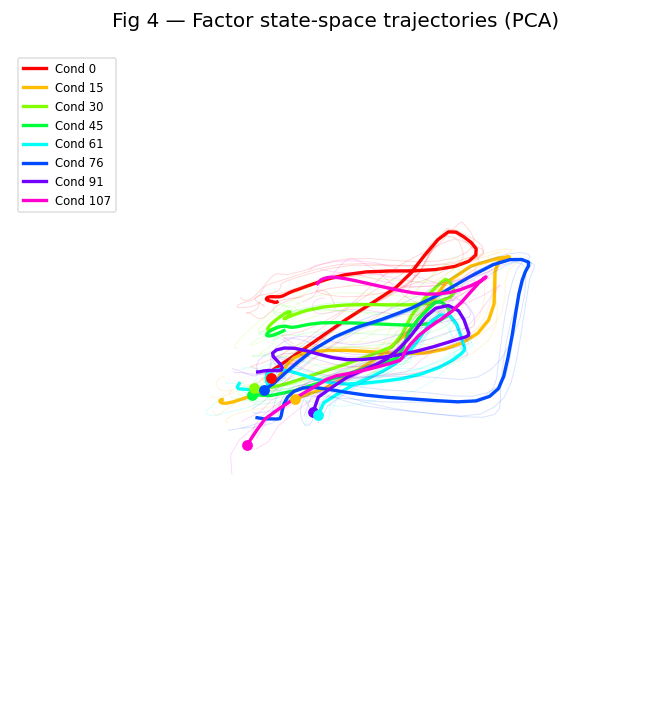

In [11]:
N_SS_CONDS      = 8
N_SS_INDIVIDUAL = 20

fac_tr  = d["train_factors"].astype(float)
fac_va  = d["valid_factors"].astype(float)
fac_all = np.concatenate([fac_tr, fac_va], axis=0)

ss_pca  = StandardScaler()
pca     = PCA(n_components=3)
pca.fit(ss_pca.fit_transform(fac_all.reshape(-1, fac_all.shape[-1])))
var_exp = pca.explained_variance_ratio_ * 100

labels_va    = cond_labels(d["valid_cond_idx"], len(fac_va))
unique_conds = np.array([c for c in np.unique(labels_va) if c >= 0])
sel_conds    = unique_conds[np.linspace(0, len(unique_conds) - 1, N_SS_CONDS, dtype=int)]

fac_va_lowd = pca.transform(ss_pca.transform(fac_va.reshape(-1, fac_va.shape[-1])))
fac_va_lowd = fac_va_lowd.reshape(len(fac_va), -1, 3)

rng2 = np.random.default_rng(0)
fig  = plt.figure(figsize=(7, 6))
ax   = fig.add_subplot(111, projection="3d")
for ci, c in enumerate(sel_conds):
    color     = cm.hsv(ci / N_SS_CONDS)
    trial_idx = np.where(labels_va == c)[0]
    sample    = rng2.choice(trial_idx, size=min(N_SS_INDIVIDUAL, len(trial_idx)), replace=False)
    for t_i in sample:
        ax.plot(*fac_va_lowd[t_i].T, color=color, alpha=0.15, lw=0.6)
    mean_traj = fac_va_lowd[trial_idx].mean(axis=0)
    ax.plot(*mean_traj.T, color=color, lw=2.0, label=f"Cond {c}")
    ax.scatter(*mean_traj[0], color=color, s=30, zorder=5)
ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}%)", fontsize=8)
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}%)", fontsize=8)
ax.set_zlabel(f"PC3 ({var_exp[2]:.1f}%)", fontsize=8)
ax.legend(fontsize=7, loc="upper left", framealpha=0.6)
ax.view_init(elev=20, azim=40); ax.axis("off")
fig.suptitle("Fig 4 — Factor state-space trajectories (PCA)", fontsize=12)
plt.tight_layout()
fig.savefig(BEST_TRIAL_DIR / "fig4_statespace.png", dpi=120)

## Fig 5 — Initial condition (IC) posterior distribution

PCA (2 components) of IC posterior means, coloured by condition.

**What to look for:** Tighter condition clustering than the single-run result
would indicate the optimised regularisation allowed the encoder to better
distinguish trial types from their initial neural dynamics.

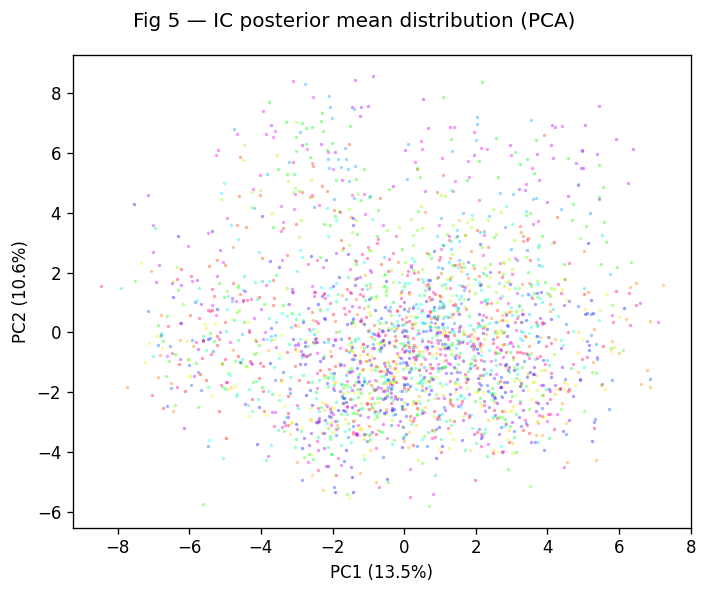

In [12]:
ic_tr  = d["train_ic_mean"].astype(float)
ic_va  = d["valid_ic_mean"].astype(float)
ic_all = np.concatenate([ic_tr, ic_va], axis=0)

labels_tr2 = cond_labels(d["train_cond_idx"], len(ic_tr))
labels_va2 = cond_labels(d["valid_cond_idx"],  len(ic_va))
labels_all = np.concatenate([labels_tr2, labels_va2])

ss2   = StandardScaler()
pca2  = PCA(n_components=2)
ic_2d = pca2.fit_transform(ss2.fit_transform(ic_all))
var2  = pca2.explained_variance_ratio_ * 100

unique_all = np.array([l for l in np.unique(labels_all) if l >= 0])
n_unique   = len(unique_all)

fig, ax = plt.subplots(figsize=(6, 5))
for c in unique_all:
    mask_c = labels_all == c
    ax.scatter(ic_2d[mask_c, 0], ic_2d[mask_c, 1],
               color=cm.hsv(c / n_unique), s=4, alpha=0.4, linewidths=0)
ax.set_xlabel(f"PC1 ({var2[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({var2[1]:.1f}%)")
fig.suptitle("Fig 5 — IC posterior mean distribution (PCA)", fontsize=12)
plt.tight_layout()
fig.savefig(BEST_TRIAL_DIR / "fig5_ic_dist.png", dpi=120)

## Summary

In [13]:
gain = r2_fac.mean() - r2_spk.mean()
print("══ Summary ══════════════════════════════════════════════════════════════")
print(f"  Best trial            : {best_trial_id}  "
      f"(recon_smth = {completed.iloc[0]['best_recon_smth']:.3f}"
      f" at epoch {int(completed.iloc[0]['best_epoch'])})")
print(f"  PSTH R²               : {psth_r2:.3f}  (1.0 = perfect condition-averaged fit)")
print(f"  Decoding R² (factors) : {r2_fac.mean():.3f}  (mean over x/y velocity)")
print(f"  Decoding R² (spikes)  : {r2_spk.mean():.3f}  (mean over x/y velocity)")
print(f"  LFADS gain            : {gain:+.3f}  "
      f"({'factors better' if gain > 0 else 'spikes better'})")
print("════════════════════════════════════════════════════════════════════════")
print(f"\nFigures saved to: {BEST_TRIAL_DIR}")

══ Summary ══════════════════════════════════════════════════════════════
  Best trial            : run_model_7ec2b_00000  (recon_smth = 0.211 at epoch 686)
  PSTH R²               : 0.926  (1.0 = perfect condition-averaged fit)
  Decoding R² (factors) : 0.869  (mean over x/y velocity)
  Decoding R² (spikes)  : 0.234  (mean over x/y velocity)
  LFADS gain            : +0.635  (factors better)
════════════════════════════════════════════════════════════════════════

Figures saved to: ../runs/lfads-torch-example/nlb_mc_maze/260520_exampleMulti/run_model_7ec2b_00000
